# StePPO quickstart

Load a released StePPO model, solve an ODE task with it, compare it with PID,
and use it as a step-size controller inside your own `diffrax` solve. The
models are downloaded from Hugging Face on first use:
[`MKoumans/sd`](https://huggingface.co/MKoumans/sd) (scalar decay),
[`MKoumans/vdp`](https://huggingface.co/MKoumans/vdp) (Van der Pol) and
[`MKoumans/bru`](https://huggingface.co/MKoumans/bru) (Brusselator).

Run it after `uv sync` (see the [README](../README.md)), in any Jupyter
front end (e.g. `uv run --with jupyterlab jupyter lab`). Select a GPU with the
`GPUS` environment variable, e.g. `GPUS=0 uv run --with jupyterlab jupyter lab`.

On Windows, run `steppo jupyter` from the repository root instead and open the
link it prints; this starts the dev container (see
[Windows](../docs/installation.md#windows-docker-desktop-or-podman)).

## 1. Solve one task from the command line

`steppo solve <system> --xi <value>` solves task ξ (λ, μ or B) with StePPO and
with diffrax's PID controller, and reports the step counts (accepted +
rejected) and the log10 relative error against a tight-tolerance reference.
It also saves a plot of the trajectories and a GIF of the solve progress to
`outputs/example/` (choose the path with `--plot traj.png`).

In [1]:
!steppo solve van_der_pol --xi 50

steppo     175 steps, reached t_end, mean log10 error -4.24, final log10 error -6.22
pid        378 steps, reached t_end, mean log10 error -3.67, final log10 error -4.97


## 2. The same from Python

`solve` returns every trajectory: `results["reference"]`, `results["steppo"]`
and `results["pid"]`, each with the accepted time points `ts`, states `ys`,
`steps` and `completed`; the controllers also carry `log10_e`, the error
against the reference at each step. `plot` draws each state component and the
error.

steppo: 175 steps, reached t_end: True
pid: 378 steps, reached t_end: True


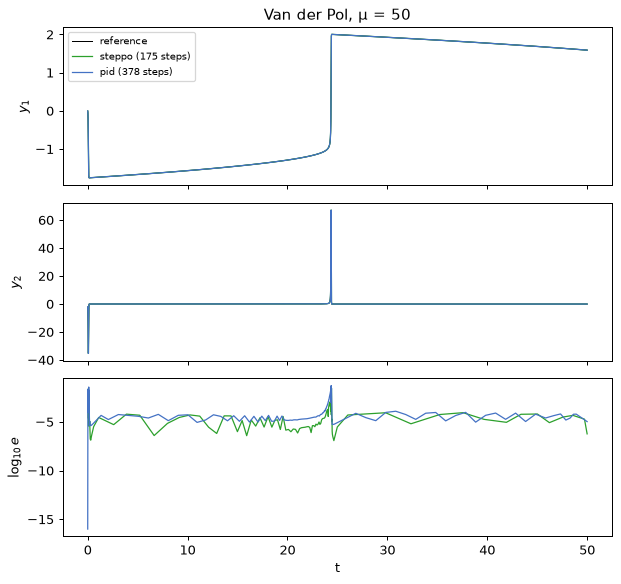

In [2]:
from steppo.utils.device import setup_devices
from steppo.cli import load_paper_model, plot, solve

setup_devices(verbose=False)  # before the first JAX computation: honours GPUS (e.g. GPUS=0 or GPUS=cpu)
artifact = load_paper_model("van_der_pol")
results = solve("van_der_pol", xi=50.0, artifact=artifact)
for name in ("steppo", "pid"):
    print(f"{name}: {results[name]['steps']} steps, reached t_end: {results[name]['completed']}")
plot(results, "Van der Pol, μ = 50");

Any system and task value works the same way, e.g. the Brusselator at B = 5:

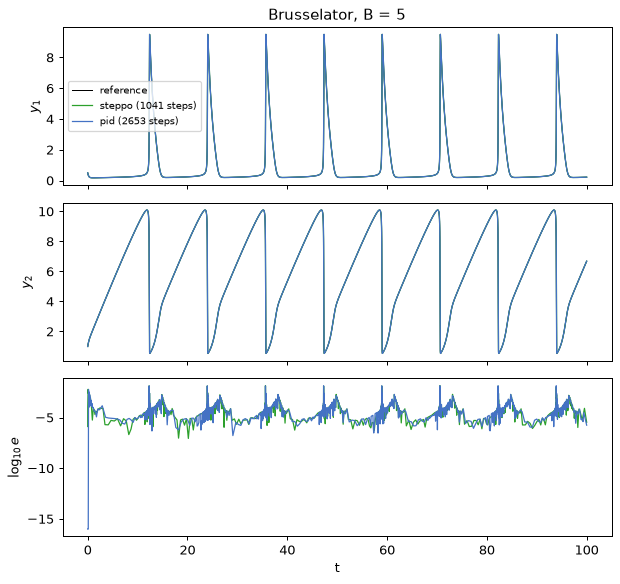

In [3]:
plot(solve("brusselator", xi=5.0), "Brusselator, B = 5");

## 3. StePPO as a diffrax step-size controller

`artifact.controller` is a `diffrax.AbstractAdaptiveStepSizeController` (a
`LearnedController`), so it replaces `diffrax.PIDController` in any
`diffeqsolve` call and runs inside diffrax's compiled solve loop. At every
step its encoder updates the belief about the unknown task from the solver's
error estimates, and the policy picks the next step size from that belief.

Below, the Van der Pol oscillator is written directly in diffrax. Use the
setting the model was trained in: the implicit `Kvaerno5` solver whose Newton
(`VeryChord`) root finder uses the model's tolerances (`artifact.config.env`),
the RMS norm and lineax's automatic linear solver, and the task parameter as
the first entry of `args`. With these settings the step counts equal those of
`steppo solve` above; diffrax's default root-finder settings give slightly
different steps.

In [4]:
import diffrax
import jax
import jax.numpy as jnp
import lineax
import optimistix

env = artifact.config.env  # solver settings the model was trained with
jax.config.update("jax_enable_x64", env.precision == "float64")


def van_der_pol(t, y, args):
    mu = args[0]
    return jnp.stack([y[1], mu * (1 - y[0] ** 2) * y[1] - y[0]])


root_finder = diffrax.VeryChord(rtol=env.rtol, atol=env.atol, norm=optimistix.rms_norm,
                                linear_solver=lineax.AutoLinearSolver(well_posed=None))
solver = diffrax.Kvaerno5(root_finder=root_finder)
controllers = {
    "StePPO": artifact.controller,
    "PID": diffrax.PIDController(rtol=env.rtol, atol=env.atol, dtmin=env.dt_min, dtmax=env.dt_max,
                                 force_dtmin=False),
}
mu = 50.0
for name, controller in controllers.items():
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(van_der_pol), solver, t0=0.0, t1=env.t_end, dt0=env.dt0,
        y0=jnp.array([0.0, -2.0]), args=jnp.array([mu, 0.0]),
        stepsize_controller=controller, saveat=diffrax.SaveAt(t1=True), max_steps=10_000,
    )
    accepted, rejected = int(sol.stats["num_accepted_steps"]), int(sol.stats["num_rejected_steps"])
    print(f"{name:6s}: {accepted + rejected} steps ({accepted} accepted), y(t_end) = {sol.ys[-1]}")

StePPO: 175 steps (158 accepted), y(t_end) = [ 1.58993318 -0.02080396]
PID   : 378 steps (198 accepted), y(t_end) = [ 1.58995133 -0.02080341]


## 4. Reproducing the paper figures

One script per figure, with the released models (`--mode import`) or with
models you train yourself (`--mode execute`): see
[REPRODUCE.md](../REPRODUCE.md).